# Лабораторная работа 3
#### Меркулов Роман Александрович
#### Группа 6


  





## Цель работы
Изучение методов глобальной интерполяции (полиномы Лагранжа и Ньютона) и их применение для аппроксимации функции на равномерной и чебышевской сетках, а также интерполяция изображений





## Ход работы

## Подготовка к проекту
Импортируем необходимые библиотеки и определяем аналитическую функцию

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from typing import List, Callable

# Для отображения графиков прямо в блокноте
%matplotlib inline

# Аналитическая функция
def f(x):
    return -np.sinc(1.5 * x)

## Задание 3.3.1. Задание по глобальной интерполяции
### 1.1. Загружаем данные из файла, представляемые собой значения функции f(x) = -sinc(1.5x) на интервале [-5,5]


In [9]:
try:
    data = pd.read_csv('Task_Data_Interpolation.csv', sep=';')
    x_data = data['x'].values
    y_data = data['y'].values
except FileNotFoundError as e:
    raise RuntimeError(f"Не найден файл с данными: {e}")

### 1.2. Отображаем исходные данные на графике

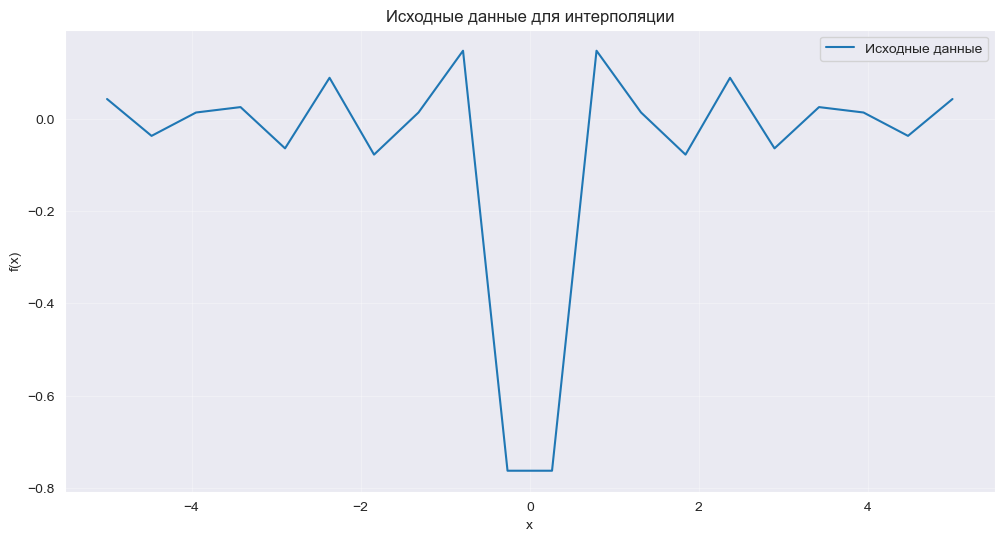

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(x_data, y_data, label='Исходные данные')
plt.title('Исходные данные для интерполяции')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### 2. Реализация функций, реализующие процедуру интерполяции

In [11]:
def build_lagrange_interpolation(x_points: List[float], y_points: List[float]) -> Callable:
    """Строит интерполяционный полином Лагранжа"""
    n = len(x_points)
    
    def L_n(x):
        """Вычисляет значение полинома Лагранжа в точке x"""
        y = 0
        for i in range(n):
            c_i = 1
            for j in range(n):
                if i != j:
                    c_i *= (x - x_points[j]) / (x_points[i] - x_points[j])
            y += c_i * y_points[i]
        return y
    
    return L_n

def build_newton_interpolation(x_points: List[float], y_points: List[float]) -> Callable:
    """Строит интерполяционный полином Ньютона"""
    n = len(x_points)
    
    divided_diff = {}
    
    # Нулевой порядок — значения функции
    for i in range(n):
        divided_diff[(i, i)] = y_points[i]
        
    # Вычисляем разности более высоких порядков, начиная с 1 "табличным методом"
    for k in range(1, n):
        for i in range(n - k):
            j = i + k
            divided_diff[(i, j)] = (divided_diff[(i + 1), j] - divided_diff[(i, j - 1)]) / (x_points[j] - x_points[i])
            
    def N_n(x):
        """Вычисляет значение полинома Ньютона в точке x"""
        y = y_points[0]
        multiply = 1
        for k in range(1, n):
            multiply *= (x - x_points[k - 1])
            y += divided_diff[(0, k)] * multiply
        return y
    
    return N_n         

Эти функции build возвращают построенные полиномы, в которые мы можем подставить значение x и получить значение полиномов
При построении полинома Ньютона я для вычисления разделенных разностей использую метод "таблицы", который мы рассматривали на практике. Дебаг проводил в файле test_devide_diff.py Единственное отличие от того, что мы рассматривали на паре, я учитываю разность x(так как сетка у нас неравномерная)

### 3 Создадим сам график сравнения методов

In [12]:
def plot_interpolation_comparison(x_nodes: List[float], y_nodes: List[float], f: callable, method: callable, method_name, n = 300):
    x_for_func = np.linspace(min(x_nodes), max(x_nodes), n)
    y_func = f(x_for_func)
    
    P = method(x_nodes, y_nodes)
    
    x_for_interpolation = []
    x_added = []
    for i in range(len(x_nodes) - 1):
        x_for_interpolation.append(x_nodes[i])
        x_for_interpolation.append((x_nodes[i] + x_nodes[i + 1]) / 2)
        x_added.append((x_nodes[i] + x_nodes[i + 1]) / 2)
    x_for_interpolation.append(x_nodes[-1])
    
    y_interpolation = np.array([P(x_cur) for x_cur in x_for_interpolation])
    y_added = np.array([P(x_cur) for x_cur in x_added])
    
    plt.figure(figsize=(12, 6))
    plt.plot(x_for_func, y_func, color='black', label='Точная функция')
    plt.plot(x_nodes, y_nodes, 'o', color='red', markersize=4, label='Исходные узлы')
    plt.plot(x_added, y_added, 's', color='green', markersize=4, label='Добавленные точки')
    plt.plot(x_for_interpolation, y_interpolation, '--', color='blue', label=f'Полином {method_name} (с добавленными точками)')
    plt.title(f'Интерполяция полиномом {method_name}', fontsize=14)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('f(x)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

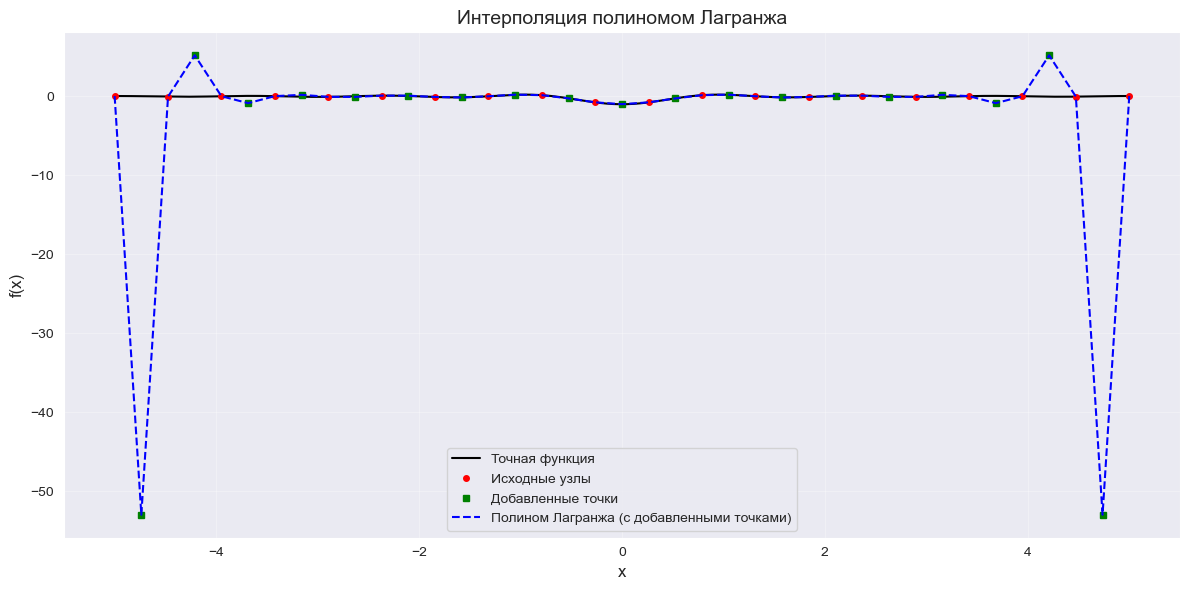

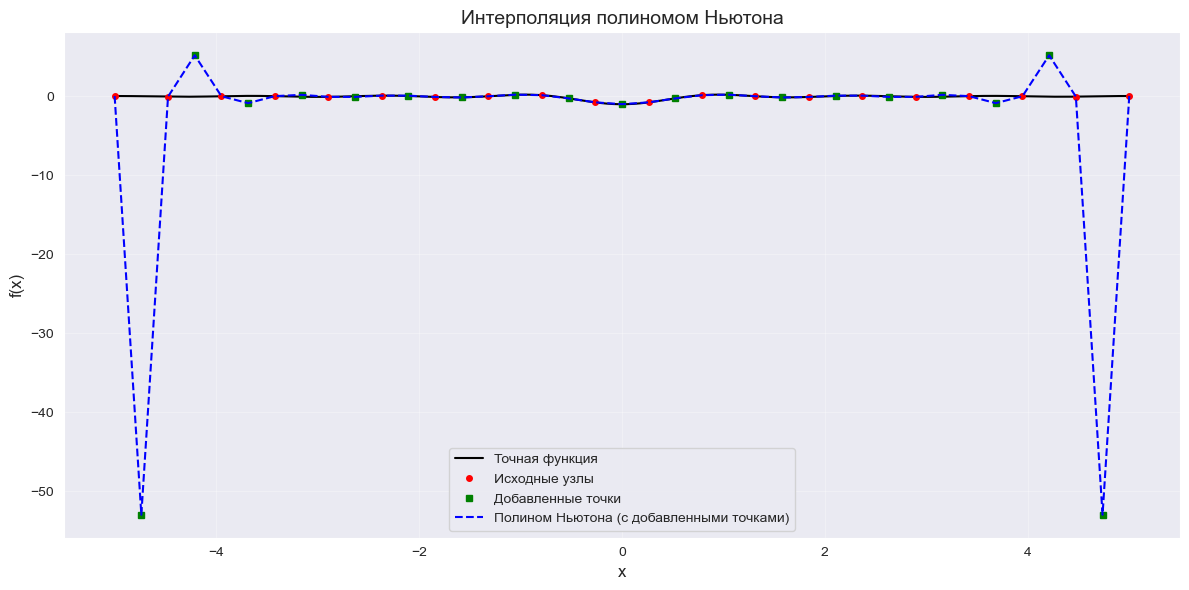

In [13]:
plot_interpolation_comparison(x_data, y_data, f, method=build_lagrange_interpolation, method_name='Лагранжа',)

plot_interpolation_comparison(x_data, y_data, f, method=build_newton_interpolation, method_name='Ньютона')

Полиномы Лагранжа и Ньютона идентичны — они представляют один и тот же интерполяционный многочлен. Различия в значениях обусловлены только ошибками округления (порядка 10^-15), что подтверждает корректность реализаций обоих методов. В центре интервала график интерполяции совпадает с графиком самой функции, но на границах интервала интерполирования точность падает значительно

### 4.1 Создадим функцию для генерации узлов Чебышева

In [14]:
def chebyshev_nodes(a, b, n) -> np.array:
    x_cheb = []
    for k in range(1, n + 1):
        x_k = (a + b) / 2 + (b - a) / 2 * np.cos((2 * k - 1) / (2 * n) * np.pi)
        x_cheb.append(x_k)
    return np.array(x_cheb)

Теперь генерируем набор из 20 точек Чебышева

In [15]:
a, b = -5, 5
n_points = 20

x_cheb = chebyshev_nodes(a, b, n_points)
y_cheb = f(x_cheb)

Используем функцию построения графика из 3 задания, но теперь с точками Чебышева

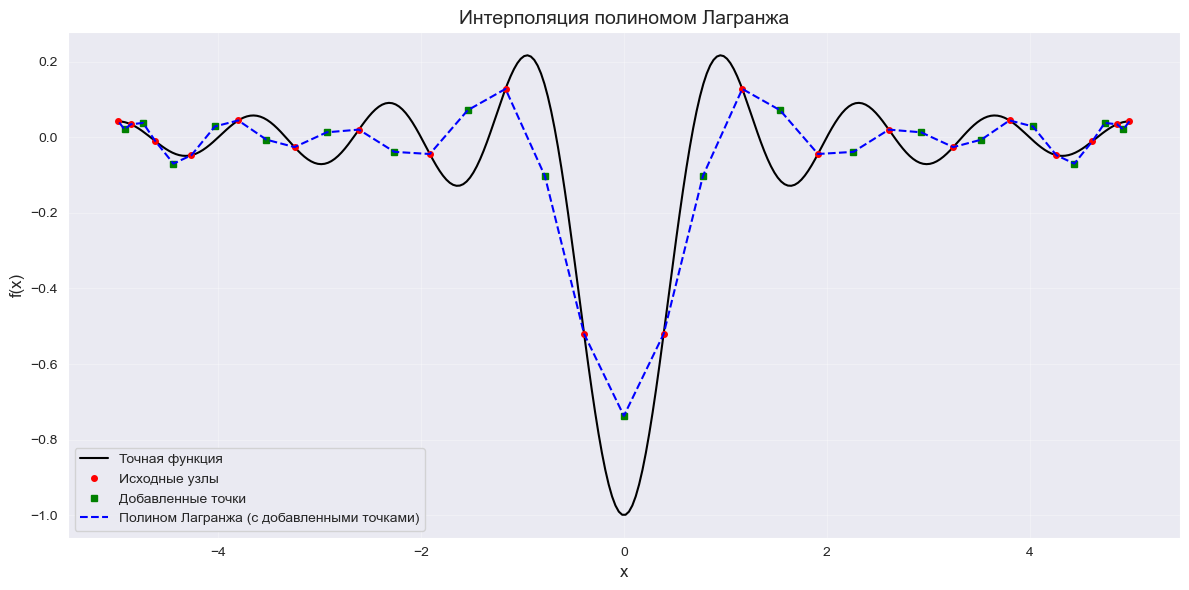

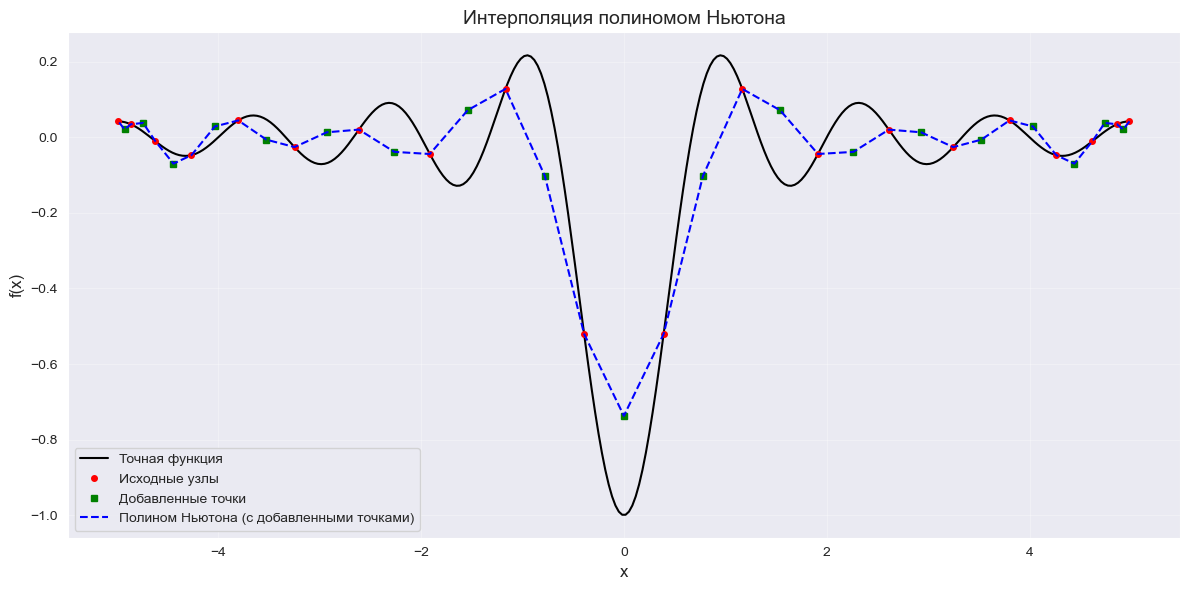

In [16]:
plot_interpolation_comparison(x_cheb, y_cheb, f, method=build_lagrange_interpolation, method_name='Лагранжа',)

plot_interpolation_comparison(x_cheb, y_cheb, f, method=build_newton_interpolation, method_name='Ньютона')

## Выводы
1. Методы Лагранжа и Ньютона дают идентичные результаты, что подтверждает единственность интерполяционного полинома, однако метод Ньютона удобнее для добавления новых узлов.

2. На равномерной сетке мы наблюдаем, что погрешность на краях интервала достигает десятков и сотен единиц, что делает глобальную интерполяцию на равномерной сетке непригодной.

3. Использование узлов Чебышева кардинально улучшает точность — максимальная погрешность снижается.

4. Выбор узлов интерполяции критически важен — равномерная сетка приводит к катастрофической погрешности, в то время как чебышевская сетка обеспечивает высокую точность на всём интервале.



# 3.3.2 Задание по кусочной интерполяции

### 1. Загружаем изображение

Тип данных: uint8
Размер: (121, 103, 3)
Диапазон значений: [0, 255]
Количество пикселей: 37389
img[0,0] = [255 255 255]
img[0,1] = [255 255 255]
img[0,2] = [255 255 255]
img[0,3] = [255 255 255]
img[0,4] = [255 255 255]
img[0,5] = [255 255 255]
img[0,6] = [255 255 255]
img[0,7] = [255 255 255]
img[0,8] = [255 255 255]
img[0,9] = [255 255 255]
img[1,0] = [255 255 255]
img[1,1] = [255 255 255]
img[1,2] = [255 255 255]
img[1,3] = [255 255 255]
img[1,4] = [255 255 255]
img[1,5] = [255 255 255]
img[1,6] = [255 255 255]
img[1,7] = [255 255 255]
img[1,8] = [255 255 255]
img[1,9] = [255 255 255]
img[2,0] = [255 255 255]
img[2,1] = [255 255 255]
img[2,2] = [255 255 255]
img[2,3] = [255 255 255]
img[2,4] = [255 255 255]
img[2,5] = [255 255 255]
img[2,6] = [255 255 255]
img[2,7] = [255 255 255]
img[2,8] = [255 255 255]
img[2,9] = [255 255 255]
img[3,0] = [255 255 255]
img[3,1] = [255 255 255]
img[3,2] = [255 255 255]
img[3,3] = [255 255 255]
img[3,4] = [255 255 255]
img[3,5] = [255 255 255]
img[3

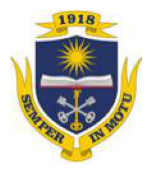

In [27]:
img = plt.imread('task_vsu_gerb.jpeg')

for i in range(100):
    for j in range(100):
        print(f"img[{i},{j}] = {img[i, j]}")
        
plt.figure(figsize=(2, 2))
plt.imshow(img)
plt.axis('off')
plt.grid('off')
plt.show()

Как мы видим, изображение представляет из себя тройной вложенный массив(первый вложенный - строки, второй - столбцы, третий - каждый пиксель (R,G,B))

## 2. Функции, увеличивающие размер изображения

In [51]:
def nearest_neighbor_interpolation(img, scale_factor):
    h, w, c = img.shape
    new_h = h * scale_factor
    new_w = w * scale_factor

    img_new = np.zeros((new_h, new_w, c), dtype=img.dtype)
    
    for i in range(new_h):
        for j in range(new_w):
            src_i = min(int(round(i / scale_factor)), h - 1)
            src_j = min(int(round(j / scale_factor)), w - 1)
            
            for channel in range(c):
                img_new[i, j, channel] = img[src_i, src_j, channel]
    
    return img_new


def linear_interpolation_horizontal(img, scale_factor):
    h, w, c = img.shape
    new_h = h
    new_w = w * scale_factor
    
    img_float = img.astype(np.float64)
    img_new = np.zeros((new_h, new_w, c), dtype=np.uint8)
    
    for i in range(new_h):
        for j in range(new_w):
            x = j / scale_factor
            
            x_left = int(np.floor(x))
            x_right = min(x_left + 1, w - 1)
            
            dx = x - x_left
            
            for channel in range(c):
                p_left = img_float[i, x_left, channel]
                p_right = img_float[i, x_right, channel]
                
                # Линейная интерполяция
                value = p_left + (p_right - p_left) * dx
                img_new[i, j, channel] = int(max(0, min(255, value)))
    
    return img_new


def linear_interpolation_vertical(img, scale_factor):
    h, w, c = img.shape
    new_h = h * scale_factor
    new_w = w
    
    img_float = img.astype(np.float64)
    img_new = np.zeros((new_h, new_w, c), dtype=np.uint8)
    
    for i in range(new_h):
        for j in range(new_w):
            y = i / scale_factor
    
            y_top = int(np.floor(y))  
            y_bottom = min(y_top + 1, h - 1)  
            
            dy = y - y_top
            
            for channel in range(c):
                p_top = img_float[y_top, j, channel]
                p_bottom = img_float[y_bottom, j, channel]
                
                # Линейная интерполяция
                value = p_top + (p_bottom - p_top) * dy
                img_new[i, j, channel] = int(max(0, min(255, value)))
    
    return img_new


def linear_interpolation_both(img, scale_factor):
    # Сначала увеличиваем по горизонтали, потом по вертикали.
    img_temp = linear_interpolation_horizontal(img, scale_factor)
    img_new = linear_interpolation_vertical(img_temp, scale_factor)
    return img_new


def bilinear_interpolation(img, scale_factor):
    h, w, c = img.shape
    new_h = int(h * scale_factor)
    new_w = int(w * scale_factor)
    
    img_float = img.astype(np.float64)
    img_new = np.zeros((new_h, new_w, c), dtype=np.uint8)
    
    for i in range(new_h):
        for j in range(new_w):
            y = i / scale_factor
            x = j / scale_factor
            
            x_left = int(np.floor(x))          
            x_right = min(x_left + 1, w - 1)        
            y_top = int(np.floor(y))         
            y_bottom = min(y_top + 1, h - 1)
            
            dx = x - x_left
            dy = y - y_top
            
            for channel in range(c):
                f00 = img_float[y_top, x_left, channel] 
                f01 = img_float[y_top, x_right, channel]
                f10 = img_float[y_bottom, x_left, channel] 
                f11 = img_float[y_bottom, x_right, channel]
                
                # Билинейная интерполяция
                value = (1-dx)*(1-dy)*f00 + dx*(1-dy)*f01 + (1-dx)*dy*f10 + dx*dy*f11
                
                img_new[i, j, channel] = int(max(0, min(255, value)))
    
    return img_new


def bicubic_interpolation(img, scale_factor):
    h, w, c = img.shape
    new_h = int(h * scale_factor)
    new_w = int(w * scale_factor)

    img_float = np.pad(img, ((2, 2), (2, 2), (0, 0)), mode='reflect').astype(np.float64)
    img_new = np.zeros((new_h, new_w, c), dtype=np.uint8)
    
    for i in range(new_h):
        for j in range(new_w):
            y = i / scale_factor
            x = j / scale_factor
            
            x_left = int(np.floor(x))
            y_top = int(np.floor(y))
            
            dx = x - x_left
            dy = y - y_top
            
            # Сдвиг из-за паддинга (+2)
            x0 = x_left + 2
            y0 = y_top + 2
            
            for channel in range(c):
                # Берём 4×4 = 16 пикселей
                # 4 строки: y0-1, y0, y0+1, y0+2
                rows = []
                for r in range(-1, 3):
                    # 4 пикселя в строке: x0-1, x0, x0+1, x0+2
                    p0 = img_float[y0 + r, x0 - 1, channel]
                    p1 = img_float[y0 + r, x0, channel]
                    p2 = img_float[y0 + r, x0 + 1, channel]
                    p3 = img_float[y0 + r, x0 + 2, channel]
                    
                    # Кубическая интерполяция по X
                    value_x = 0.5 * ( (-p0 + 3*p1 - 3*p2 + p3) * dx**3 + (2*p0 - 5*p1 + 4*p2 - p3) * dx**2 + (-p0 + p2) * dx + 2*p1 )
                    rows.append(value_x)
                
                # Кубическая интерполяция по Y
                value = 0.5 * ( (-rows[0] + 3*rows[1] - 3*rows[2] + rows[3]) * dy**3 + (2*rows[0] - 5*rows[1] + 4*rows[2] - rows[3]) * dy**2 + (-rows[0] + rows[2]) * dy + 2*rows[1] )
                
                img_new[i, j, channel] = int(max(0, min(255, value)))
    
    return img_new

1. Ближайший сосед - новый пиксель получает значение самого близкого исходного пикселя
2. Линейная (только по горизонтали) - интерполяция между двумя соседними пикселями по горизонтали. value = p_left + (p_right - p_left) * dx, dx = x - x_left
3. Линейная (только по вертикали) - интерполяция между двумя соседними пикселями по вертикали. value = p_top + (p_bottom - p_top) * dy, dy = y - y_top
4. Линейная - две последовательные линейные интерполяции: сначала по горизонтали, потом по вертикали
5. Билинейная - интерполяция с использованием 4 соседних пикселей (2×2) за один проход. value = (1-dx)\*(1-dy)\*f00 + dx\*(1-dy)\*f01 + (1-dx)\*dy\*f10 + dx\*dy\*f11, dx = x - x_left, dy = y - y_top
6. Бикубическая - Интерполяция с использованием 16 соседних пикселей (4×4) и кубического полинома. P(t) = 0.5 * ((-p0 + 3p1 - 3p2 + p3) * t^3 + (2p0 - 5p1 + 4p2 - p3) * t^2 + (-p0 + p2) * t + 2p1), t = dx, t = dy

### 2.1 Далее сама функция построения изображений для сравнения и ее использование 
Используем импорты для сохранения изображений

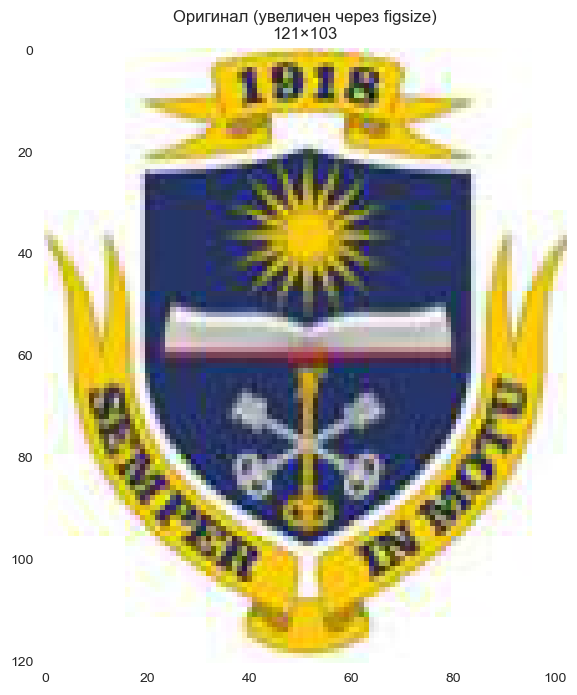

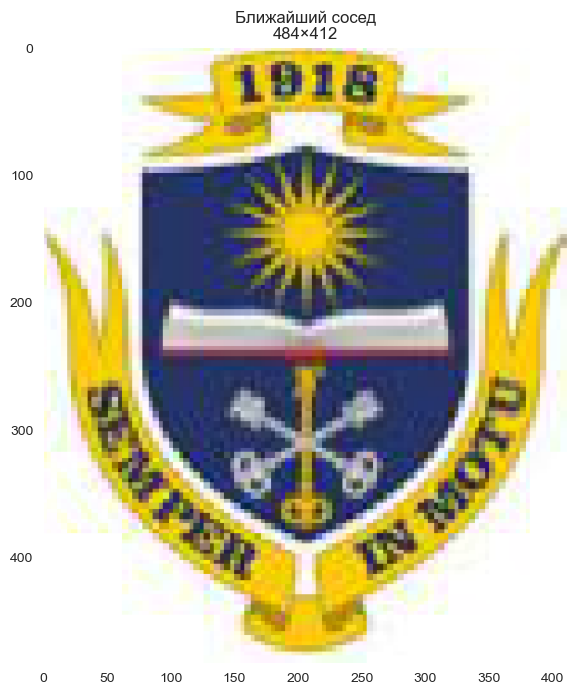

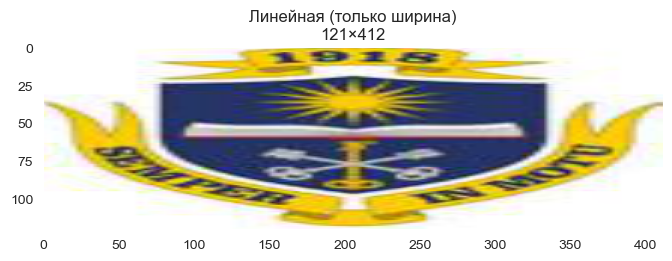

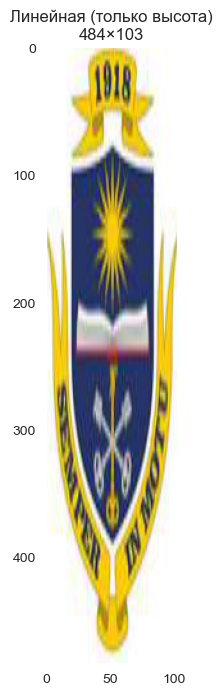

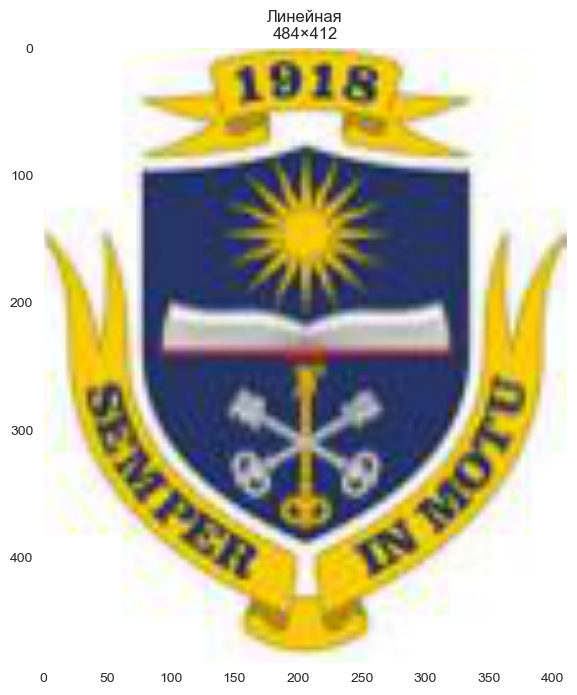

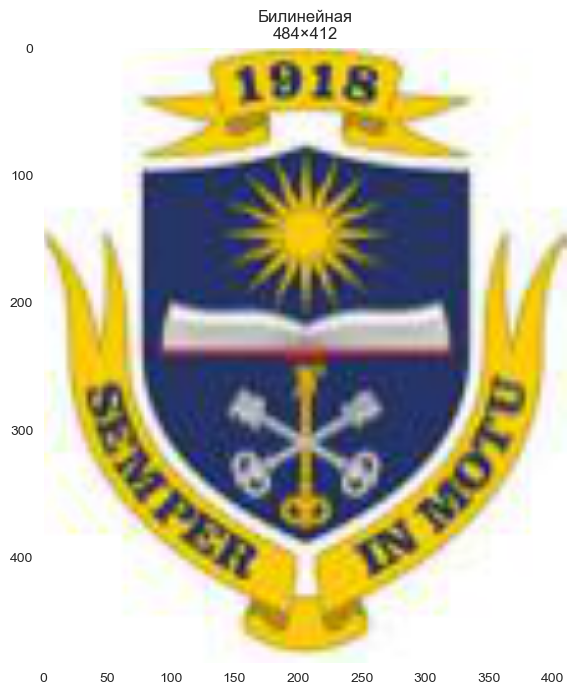

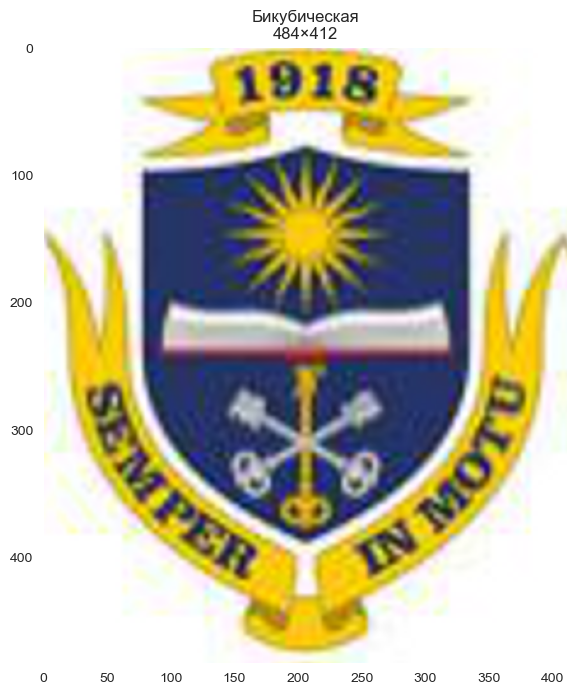

In [58]:
from PIL import Image
import os

def compare_interpolation_methods(img, scale=4, save_to_file=True, output_dir='interpolation_results', figsize=(8, 8)):
    if save_to_file and not os.path.exists(output_dir):
        os.makedirs(output_dir)


    img_nearest = nearest_neighbor_interpolation(img, scale)
    img_linear_w = linear_interpolation_horizontal(img, scale)
    img_linear_h = linear_interpolation_vertical(img, scale)
    img_linear_both = linear_interpolation_both(img, scale)
    img_bilinear = bilinear_interpolation(img, scale)
    img_bicubic = bicubic_interpolation(img, scale)
    
    if save_to_file:
        Image.fromarray(img).save(f'{output_dir}/0_original.png')
        Image.fromarray(img_nearest).save(f'{output_dir}/1_nearest.png')
        Image.fromarray(img_linear_w).save(f'{output_dir}/2_linear_width.png')
        Image.fromarray(img_linear_h).save(f'{output_dir}/3_linear_height.png')
        Image.fromarray(img_linear_both).save(f'{output_dir}/4_linear_both.png')
        Image.fromarray(img_bilinear).save(f'{output_dir}/5_bilinear.png')
        Image.fromarray(img_bicubic).save(f'{output_dir}/6_bicubic.png')
    
    methods = [
        (img, f'Оригинал (увеличен через figsize)\n{img.shape[0]}×{img.shape[1]}'),
        (img_nearest, f'Ближайший сосед\n{img_nearest.shape[0]}×{img_nearest.shape[1]}'),
        (img_linear_w, f'Линейная (только ширина)\n{img_linear_w.shape[0]}×{img_linear_w.shape[1]}'),
        (img_linear_h, f'Линейная (только высота)\n{img_linear_h.shape[0]}×{img_linear_h.shape[1]}'),
        (img_linear_both, f'Линейная\n{img_linear_both.shape[0]}×{img_linear_both.shape[1]}'),
        (img_bilinear, f'Билинейная\n{img_bilinear.shape[0]}×{img_bilinear.shape[1]}'),
        (img_bicubic, f'Бикубическая\n{img_bicubic.shape[0]}×{img_bicubic.shape[1]}')
    ]
    
    for method_img, title in methods:
        plt.figure(figsize=figsize)
        plt.imshow(method_img)
        plt.grid(False)
        plt.title(title)
        plt.show()

compare_interpolation_methods(img, scale=4, figsize=(2 * 4, 2 * 4))

## Выводы
Ближайший сосед — самый быстрый, но даёт пикселизацию; линейные методы сглаживают по одному или двум направлениям; билинейная (4 пикселя) — оптимальный баланс скорости и качества; бикубическая (16 пикселей) — максимальное качество, но медленнее. В отличие от этих методов, figsize не выполняет интерполяцию — он просто растягивает изображение при отображении, не добавляя новые пиксели, поэтому его нельзя использовать для реального увеличения изображения, а только для визуального растяжения на экране.